<a href="https://colab.research.google.com/github/gyuhyeongkim412-creator/financial-data-bootcamp/blob/main/%ED%98%91%EC%97%85_%ED%95%84%ED%84%B0%EB%A7%81_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```python
#실습 #행렬분해 #FunkSVD #ALS #NMF
# Lab 06. 협업 필터링 - 모델 기반 (FunkSVD / ALS / NMF) (Exercise)

> **관련**: [[06_협업_필터링_모델_기반]]
> MovieLens 100K | Google Colab Ready

---

## 1. 환경 설정 & 데이터 로드 + Leave-One-Out 분할

이 섹션에서는 MovieLens 100K 데이터를 불러오고, 모델 학습에 필요한 형태로 전처리합니다. 핵심은 **Leave-One-Out** 분할인데, 각 사용자의 마지막 상호작용 하나를 테스트용으로 빼두고 나머지로 학습합니다. 이 방식은 "미래에 사용자가 볼 영화를 예측할 수 있는가?"를 평가하기에 적합합니다.

```python
# 필요한 패키지 설치 (Colab 환경에서 실행)
!pip install -q numpy pandas scikit-learn scipy

import os
# 데이터셋이 없으면 다운로드 — 이미 있으면 건너뜀
if not os.path.exists('ml-100k'):
    !wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
    !unzip -q ml-100k.zip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# ── 데이터 로드 ──
# MovieLens 100K는 탭(\t) 구분이며 4개 열: user_id, item_id, rating, timestamp
cols = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('ml-100k/u.data', sep='\t', names=cols)

# ── 유저/아이템 ID를 0-based 인덱스로 매핑 ──
# 원본 ID는 1부터 시작하고 중간에 빈 번호가 있을 수 있으므로
# 행렬 인덱싱을 위해 0, 1, 2, ... 연속 번호로 변환
user_ids = sorted(df['user_id'].unique())
item_ids = sorted(df['item_id'].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}  # {원본ID: 새인덱스} 딕셔너리
item2idx = {v: i for i, v in enumerate(item_ids)}
n_users, n_items = len(user_ids), len(item_ids)
df['u'] = df['user_id'].map(user2idx)  # 새 인덱스 열 추가
df['i'] = df['item_id'].map(item2idx)

# ── Leave-One-Out 분할 ──
# 각 유저의 상호작용을 시간순 정렬 후, 가장 마지막 것을 테스트로 분리
# 이렇게 하면 "과거 데이터로 미래를 예측"하는 현실적인 평가가 됨
df = df.sort_values(['u', 'timestamp'])
test_df = df.groupby('u').last().reset_index()  # 각 유저의 마지막 상호작용
# train에서 test에 해당하는 행만 제거하기 위해 merge + indicator 사용
train_df = df.___(test_df[['u', 'i', 'timestamp']], on=['u', 'i', 'timestamp'], how='left', indicator=True)
train_df = train_df[train_df['_merge'] == 'left_only'].drop(columns='_merge')

# ── 평점 행렬 구성 (train only) ──
# R[u][i] = 유저 u가 아이템 i에 준 평점 (없으면 0)
# 이 행렬이 행렬 분해의 입력이 됨: R ≈ P × Q^T
R = np.___((n_users, n_items))
for _, row in train_df.___():
    R[int(row['u']), int(row['i'])] = row['rating']

# ── 테스트 쌍과 유저별 긍정 아이템 (implicit: rating >= 4) ──
# 평가 시 "긍정 아이템 vs 부정 아이템"을 비교해야 하므로 준비
test_pairs = list(zip(test_df['u'].___, test_df['i'].values))
user_positive = defaultdict(___)  # {유저: {좋아한 아이템들}}
for _, row in df.___():
    if row['rating'] >= 4:  # 4점 이상 = "좋아함"으로 간주
        user_positive[int(row['u'])].add(int(row['i']))
all_items = np.arange(n_items)  # 전체 아이템 인덱스 배열

# ── 장르 정보 로드 (시각화용) ──
# 19개 장르에 대한 one-hot 인코딩 — t-SNE 시각화에서 색상 구분에 사용
genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
              'Romance','Sci-Fi','Thriller','War','Western']
items_df = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', header=None,
                        names=['id','title','date','video_date','url'] + genre_cols)
item_genres = items_df[genre_cols].___  # (n_items, 19) 장르 원핫 행렬

print(f"Users: {n_users}, Items: {n_items}")
print(f"Train: {len(train_df)}, Test: {len(test_pairs)}")
```

> 💡 **이해 포인트**: Leave-One-Out은 추천 시스템에서 가장 많이 쓰이는 평가 방식 중 하나입니다. 각 유저의 마지막 1개 상호작용만 테스트로 빼므로 데이터 낭비가 적고, "다음에 볼 아이템을 맞출 수 있는가?"라는 현실적 질문에 답합니다.

---

## 2. 공통 평가 함수

모든 모델을 공정하게 비교하기 위한 평가 함수입니다. 각 유저에 대해 "정답 아이템 1개 + 랜덤 부정 아이템 99개" 중에서 정답을 상위 10개 안에 넣을 수 있는지 평가합니다. 이 방식은 He et al. (2017) 논문에서 제안된 표준 프로토콜입니다.

```python
def evaluate_model(score_fn, test_pairs, user_positive, all_items, k=10, num_neg=99):
    """
    Leave-One-Out + 샘플링 기반 HR@k, nDCG@k 평가
    - score_fn: 유저와 아이템 목록을 받아 점수 배열을 반환하는 함수
    - HR@k (Hit Rate): 정답이 Top-K에 포함된 유저 비율
    - nDCG@k: 정답의 순위가 높을수록 높은 점수 (위치 가중치 반영)
    """
    rng = np.random.RandomState(42)  # 재현성을 위해 시드 고정
    hits, ndcgs = [], []

    for user, pos_item in test_pairs:
        # 1단계: 부정 아이템 99개 샘플링 (유저가 좋아한 적 없는 아이템)
        neg_items = []
        user_pos = user_positive.get(user, set())
        while len(neg_items) < num_neg:
            neg = rng.choice(all_items)  # 전체 아이템 중 랜덤 선택
            if neg not in user_pos and neg != pos_item:  # 긍정 아이템 제외
                neg_items.append(neg)

        # 2단계: 정답 + 부정 아이템 합쳐서 점수 계산
        test_items = np.array(neg_items + [pos_item])  # 정답은 마지막에 위치
        scores = score_fn(user, test_items)  # 모델이 각 아이템에 매긴 점수

        # 3단계: 점수 기준 상위 K개 인덱스 추출
        top_k = np.argsort(___scores)[:___]  # 내림차순 정렬 후 상위 k개
        pos_idx = len(test_items) - 1     # 정답 아이템의 인덱스 (마지막)

        # 4단계: HR (정답이 top-k에 있으면 1, 없으면 0)
        hit = 1.0 if pos_idx in top_k else 0.0
        hits.append(hit)

        # 5단계: nDCG (정답의 순위에 따라 가중치 부여)
        # 1위면 1.0, 2위면 0.63, 3위면 0.5, ... (log 감소)
        ndcgs.append(1.0 / np.log2(np.where(top_k == pos_idx)[0][0] + 2) if hit else 0.0)

    return np.mean(hits), np.mean(ndcgs)
```

> 💡 **이해 포인트**: 왜 전체 아이템이 아닌 100개(정답 1 + 부정 99)만 비교할까요? 전체 아이템(수천~수백만)을 비교하면 계산이 너무 오래 걸리기 때문입니다. 100개 중에서 정답을 Top-10에 넣는 것은 "1000개 중 Top-100에 넣는 것"과 비슷한 난이도입니다.

---

## 3. FunkSVD (SGD 기반 행렬 분해)

FunkSVD는 행렬 분해의 가장 기본적인 형태입니다. 핵심 아이디어: **유저-아이템 평점 행렬 R을 두 개의 작은 행렬 P(유저)와 Q(아이템)의 곱으로 근사**합니다. `R ≈ P × Q^T`이며, 관측된 평점의 오차를 SGD(확률적 경사하강법)로 최소화합니다.

```python
# ── 관측된 (user, item, rating) 튜플 추출 ──
# 평점이 있는 (유저, 아이템, 평점) 조합만 모음 — SGD는 이것들만 학습에 사용
observed = [(int(r['u']), int(r['i']), r['rating']) for _, r in train_df.iterrows()]

# ── 하이퍼파라미터 설정 ──
K = 20       # 잠재 인자 차원 수 (유저/아이템을 20차원 벡터로 표현)
             # 클수록 표현력↑ 하지만 과적합 위험↑, 보통 10~200 사이
lr = 0.005   # 학습률 (한 번에 파라미터를 얼마나 바꿀지, 너무 크면 발산)
reg = 0.02   # 정규화 계수 (과적합 방지 — 파라미터가 너무 커지지 않게)
epochs = 30  # 전체 데이터를 몇 번 반복 학습할지

# ── 파라미터 초기화 ──
np.random.seed(42)
P_svd = np.random.normal(0, 0.1, (n_users, K))  # 유저 임베딩: (943, 20)
Q_svd = np.random.normal(0, 0.1, (n_items, K))  # 아이템 임베딩: (1682, 20)
# 작은 랜덤 값으로 초기화 — 0으로 하면 대칭성 때문에 학습이 안 됨

rmse_history_svd = []
for epoch in range(epochs):
    # 매 에포크마다 데이터를 섞어서 SGD의 수렴을 개선
    np.random.shuffle(observed)
    sse = 0.0  # Sum of Squared Errors

    for u, i, r in observed:
        # 1단계: 현재 파라미터로 예측값 계산
        # P_svd[u]는 유저 u의 잠재 벡터(20차원), Q_svd[i]는 아이템 i의 잠재 벡터
        # 내적(dot product) = 유저가 아이템을 얼마나 좋아할지 예측
        pred = P_svd[u] @ Q_svd[i]

        # 2단계: 오차(error) 계산
        # 실제 평점과 예측값의 차이 → 이 값이 0에 가까울수록 좋은 예측
        err = r - pred

        # 3단계: SGD 업데이트 (경사하강법)
        # P_svd[u] 업데이트: 오차를 줄이는 방향(err * Q_svd[i])으로 이동
        #   - lr: 학습률 (얼마나 크게 이동할지)
        #   - reg * P_svd[u]: L2 정규화 항 (과적합 방지, 파라미터가 너무 커지지 않게)
        P_svd[u] += lr * (err * Q_svd[i] - reg * P_svd[u])

        # Q_svd[i]도 같은 원리로 업데이트
        # ⚠️ 주의: 여기서 P_svd[u]는 이미 위에서 업데이트된 값 사용 (동시 업데이트가 아님)
        Q_svd[i] += lr * (err * P_svd[u] - reg * Q_svd[i])

        sse += err ** 2  # RMSE 계산을 위해 오차 제곱 누적

    # RMSE = √(평균 제곱 오차) — 낮을수록 예측이 정확
    rmse = np.sqrt(sse / len(observed))
    rmse_history_svd.append(rmse)
    if (epoch + 1) % 10 == 0:
        print(f"[FunkSVD] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수: 내적으로 예측 점수 계산 ──
# 추천 시 유저 u에 대해 모든 후보 아이템의 점수를 구한 뒤 상위 K개를 선택
def funksvd_score(user, items):
    return Q_svd[items] @ P_svd[user]  # (아이템 수, K) × (K,) = (아이템 수,)

hr_svd, ndcg_svd = evaluate_model(funksvd_score, test_pairs, user_positive, all_items)
print(f"FunkSVD — HR@10: {hr_svd:.4f}, nDCG@10: {ndcg_svd:.4f}")
```

> 💡 **이해 포인트**: FunkSVD의 핵심 직관 — 유저와 아이템을 같은 "취향 공간"(K차원)에 넣으면, 벡터가 가까운 유저-아이템 쌍은 높은 평점을 받을 것이라 기대합니다. 예를 들어 K=20이면 "액션 선호도", "로맨스 선호도", "감독 취향" 같은 20가지 잠재 특성으로 유저와 아이템을 표현하는 셈입니다.

> ⚠️ **주의할 점**: SGD 업데이트에서 P와 Q를 동시에 업데이트하지 않고 순차적으로 업데이트합니다. 이론적으로는 동시 업데이트가 더 정확하지만, 실제로는 큰 차이가 없고 구현이 간편해 이 방식을 많이 씁니다.

---

## 4. ALS (Alternating Least Squares)

ALS는 FunkSVD와 같은 목적(R ≈ P × Q^T)을 달성하지만, **최적화 방법이 다릅니다**. P를 고정하고 Q를 최적화 → Q를 고정하고 P를 최적화를 번갈아 수행합니다. 각 단계에서 **닫힌 형태(closed-form) 해**가 존재하므로 SGD보다 빠르게 수렴합니다.

```python
K = 20          # 잠재 인자 차원
reg_als = 0.1   # 정규화 계수 (과적합 방지)
epochs_als = 20 # ALS는 SGD보다 적은 에포크에서 수렴하는 경향

np.random.seed(42)
P_als = np.random.normal(0, 0.1, (n_users, K))  # 유저 잠재 행렬
Q_als = np.random.normal(0, 0.1, (n_items, K))  # 아이템 잠재 행렬

# ── 유저별/아이템별 관측 인덱스 사전 구축 ──
# ALS는 각 유저/아이템에 대해 "관측된 평점"만 사용하므로 미리 인덱싱
user_items = defaultdict(___)  # {유저: [(아이템, 평점), ...]}
item_users = defaultdict(___)  # {아이템: [(유저, 평점), ...]}
for u, i, r in observed:
    user_items[u].append((i, r))
    item_users[i].append((u, r))

rmse_history_als = []
for epoch in range(epochs_als):
    # ── Step 1: 유저 행렬 P 업데이트 (Q 고정) ──
    # 각 유저 u에 대해: p_u = (Q_I^T Q_I + λI)^{-1} Q_I^T r_u
    # → "유저 u가 평가한 아이템들의 잠재 벡터를 이용해 최적의 유저 벡터를 한 번에 계산"
    for u in range(n_users):
        if not user_items[u]:  # 평가한 아이템이 없으면 건너뜀
            continue
        idxs = [x[0] for x in user_items[u]]       # 유저 u가 평가한 아이템 인덱스들
        rats = np.array([x[1] for x in user_items[u]])  # 해당 평점들
        Qi = Q_als[idxs]  # (평가한 아이템 수, K) — 해당 아이템들의 잠재 벡터
        # solve(Ax = b) 형태: x = A^{-1}b
        # A = Q_I^T Q_I + λI (정규화된 그람 행렬)
        # b = Q_I^T r_u (평점 가중 합)
        P_als[u] = np.linalg.solve(Qi.T @ Qi + reg_als * np.eye(K), Qi.T @ rats)

    # ── Step 2: 아이템 행렬 Q 업데이트 (P 고정) ──
    # Step 1과 동일한 원리, 유저/아이템 역할만 바꿈
    for i in range(n_items):
        if not item_users[i]:  # 평가받은 적 없는 아이템은 건너뜀
            continue
        idxs = [x[0] for x in item_users[i]]       # 아이템 i를 평가한 유저 인덱스들
        rats = np.array([x[1] for x in item_users[i]])  # 해당 평점들
        Pu = P_als[idxs]  # (평가한 유저 수, K)
        Q_als[i] = np.linalg.solve(Pu.T @ Pu + reg_als * np.eye(K), Pu.T @ rats)

    # ── RMSE 계산 ──
    sse = sum((r - P_als[u] @ Q_als[i]) ** 2 for u, i, r in observed)
    rmse = np.sqrt(sse / len(observed))
    rmse_history_als.append(rmse)
    if (epoch + 1) % 5 == 0:
        print(f"[ALS] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수 ──
def als_score(user, items):
    return Q_als[items] @ P_als[user]

hr_als, ndcg_als = evaluate_model(als_score, test_pairs, user_positive, all_items)
print(f"ALS — HR@10: {hr_als:.4f}, nDCG@10: {ndcg_als:.4f}")
```

> 💡 **이해 포인트**: ALS의 핵심 트릭 — P와 Q를 동시에 최적화하면 비볼록(non-convex) 문제이지만, **하나를 고정하면 나머지가 선형회귀 문제**가 됩니다. 선형회귀는 닫힌 형태 해가 존재하므로 한 번의 행렬 연산으로 최적값을 구할 수 있습니다. 이것이 "Alternating(교대)" 최소자승법의 의미입니다.

> 📝 **참고**: `np.linalg.solve(A, b)`는 `A^{-1} @ b`와 같지만, 역행렬을 직접 계산하지 않아 수치적으로 더 안정적이고 빠릅니다.

---

## 5. NMF (Non-negative Matrix Factorization)

NMF는 P와 Q의 **모든 값이 0 이상(비음수)**이도록 제약을 겁니다. 이 제약 덕분에 잠재 인자를 "이 유저가 이 장르를 얼마나 좋아하는지"처럼 직관적으로 해석할 수 있습니다. 음수가 없으므로 "긍정적 기여의 합"으로만 예측이 구성됩니다.

```python
K = 20          # 잠재 인자 차원
epochs_nmf = 50 # NMF는 곱셈 업데이트 규칙이 느려서 더 많은 에포크 필요
eps = 1e-9      # 0 나눗셈 방지용 아주 작은 값

np.random.seed(42)
# ── 비음수 초기화 ──
# NMF는 값이 항상 0 이상이어야 하므로 abs()로 음수 제거
P_nmf = np.abs(np.random.normal(0.5, 0.1, (n_users, K)))  # 양수 초기값
Q_nmf = np.abs(np.random.normal(0.5, 0.1, (n_items, K)))  # 양수 초기값

# 관측 마스크: 평점이 있는 위치 = 1, 없는 위치 = 0
# 관측된 평점만 학습에 사용하기 위함 (0은 "평점 없음"이지 "0점"이 아님)
mask = (R > 0).astype(float)

rmse_history_nmf = []
for epoch in range(epochs_nmf):
    # ── 곱셈 업데이트 규칙 (Lee & Seung, 2001) ──
    # 핵심 아이디어: 덧셈/뺄셈 대신 곱셈으로 업데이트하면 비음수 제약이 자동 보장됨
    # (양수 × 양수 / 양수 = 양수이므로 절대 음수가 되지 않음)

    R_hat = P_nmf @ Q_nmf.T      # 현재 파라미터로 예측 행렬 계산
    R_masked = R * mask           # 관측된 실제 평점만 남김
    R_hat_masked = R_hat * mask   # 관측된 위치의 예측값만 남김

    # ── P 업데이트 ──
    # P의 각 원소에 (실제값 기반 합) / (예측값 기반 합) 비율을 곱함
    # 실제값 > 예측값이면 비율 > 1 → 값 증가 (과소예측 보정)
    # 실제값 < 예측값이면 비율 < 1 → 값 감소 (과대예측 보정)
    P_nmf *= (R_masked @ Q_nmf) / (R_hat_masked @ Q_nmf + eps)
    P_nmf = np.maximum(P_nmf, eps)  # 수치 안정성: 극단적으로 작은 값 방지

    # P가 바뀌었으므로 예측 행렬 재계산
    R_hat = P_nmf @ Q_nmf.T
    R_hat_masked = R_hat * mask

    # ── Q 업데이트 ── (P 업데이트와 동일한 원리, 전치만 다름)
    Q_nmf *= (R_masked.T @ P_nmf) / (R_hat_masked.T @ P_nmf + eps)
    Q_nmf = np.maximum(Q_nmf, eps)

    # RMSE 계산 (관측된 위치만)
    sse = np.sum((R_masked - (P_nmf @ Q_nmf.T) * mask) ** 2)
    rmse = np.sqrt(sse / mask.sum())
    rmse_history_nmf.append(rmse)
    if (epoch + 1) % 10 == 0:
        print(f"[NMF] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수 ──
def nmf_score(user, items):
    return Q_nmf[items] @ P_nmf[user]

hr_nmf, ndcg_nmf = evaluate_model(nmf_score, test_pairs, user_positive, all_items)
print(f"NMF — HR@10: {hr_nmf:.4f}, nDCG@10: {ndcg_nmf:.4f}")
```

> 💡 **이해 포인트**: NMF의 강점은 **해석 가능성**입니다. P[u][k]가 "유저 u의 k번째 취향 강도", Q[i][k]가 "아이템 i의 k번째 속성 강도"로 해석됩니다. 모두 양수이므로 "이 유저는 이 속성을 0.8만큼 좋아하고, 이 영화는 그 속성을 0.6만큼 가지고 있다"처럼 직관적입니다.

> ⚠️ **주의할 점**: NMF의 곱셈 업데이트는 수렴이 느리고, 초기값에 따라 **지역 최적해**에 빠질 수 있습니다. 따라서 여러 번 다른 초기값으로 실행해보는 것이 좋습니다.

---

## 6. 학습 곡선 비교 & 수렴 속도

세 모델의 학습 곡선과 최종 성능을 시각적으로 비교합니다. 왼쪽 그래프에서는 "몇 에포크 만에 수렴하는가", 오른쪽에서는 "최종 추천 성능이 어떤가"를 확인할 수 있습니다.

```python
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 학습 곡선 (RMSE vs Epoch) ──
# 에포크가 진행될수록 RMSE가 낮아지는지, 어디서 수렴하는지 확인
axes[0].plot(rmse_history_svd, label='FunkSVD (SGD)', marker='o', markevery=5)
axes[0].plot(rmse_history_als, label='ALS', marker='s', markevery=3)
axes[0].plot(rmse_history_nmf, label='NMF', marker='^', markevery=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')  # 낮을수록 예측이 정확
axes[0].set_title('학습 곡선 비교')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── 모델별 HR@10, nDCG@10 비교 (막대 그래프) ──
models = ['FunkSVD', 'ALS', 'NMF']
hrs = [hr_svd, hr_als, hr_nmf]
ndcgs = [ndcg_svd, ndcg_als, ndcg_nmf]
x = np.arange(len(models))
# 두 지표를 나란히 배치 (offset -0.15, +0.15)
axes[1].bar(x - 0.15, hrs, 0.3, label='HR@10', color='steelblue')
axes[1].bar(x + 0.15, ndcgs, 0.3, label='nDCG@10', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title('모델 비교 (HR@10, nDCG@10)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
```

> 💡 **이해 포인트**: 학습 곡선에서 ALS가 적은 에포크에서 빠르게 수렴하는 것을 확인할 수 있습니다. 이는 각 스텝에서 닫힌 형태 해를 구하기 때문입니다. 반면 NMF는 곱셈 업데이트가 느려 더 많은 에포크가 필요합니다. 하지만 RMSE가 낮다고 반드시 랭킹 성능(HR, nDCG)이 좋은 것은 아닙니다 — 평점 예측과 추천 랭킹은 다른 과제입니다.

---

## 7. 잠재 인자 시각화 (t-SNE)

행렬 분해로 학습된 아이템 임베딩이 실제로 의미 있는 구조를 갖는지 확인합니다. t-SNE로 20차원 벡터를 2차원으로 투영한 후, 장르별로 색을 칠해 **같은 장르 아이템이 모여 있는지** 봅니다.

```python
from sklearn.manifold import TSNE

# ── FunkSVD 아이템 임베딩을 t-SNE로 2D 투영 ──
# t-SNE: 고차원 데이터의 이웃 구조를 보존하면서 2D로 축소하는 시각화 기법
# perplexity: "각 점이 몇 개의 이웃을 고려할지" (보통 5~50 사이)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Q_2d = tsne.___(Q_svd)  # (n_items, 20) → (n_items, 2)

# ── 대표 장르 5개만 시각화 ──
top_genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']
genre_idx = {g: genre_cols.index(g) for g in top_genres}  # 장르명 → 열 인덱스
colors = ['red', 'blue', 'green', 'purple', 'orange']

plt.figure(figsize=(10, 8))
for genre, color in zip(top_genres, colors):
    gi = genre_idx[genre]
    mask_g = item_genres[:, gi] == 1  # 해당 장르에 속하는 아이템 마스크
    # 해당 장르 아이템만 scatter로 표시
    plt.scatter(Q_2d[mask_g, 0], Q_2d[mask_g, 1], c=color, label=genre, alpha=0.5, s=15)
plt.title('FunkSVD 아이템 임베딩 t-SNE (장르별 색상)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
```

> 💡 **이해 포인트**: 만약 같은 장르의 아이템이 t-SNE 그래프에서 군집(cluster)을 이루고 있다면, 이는 행렬 분해가 **장르 정보를 직접 주지 않았는데도** 유저 행동 데이터만으로 장르와 유사한 구조를 자동으로 학습했다는 증거입니다. 이것이 잠재 인자 모델의 가장 매력적인 성질입니다.

---

## 8. 핵심 정리

| 모델 | 학습 방식 | 장점 | 단점 |
|------|-----------|------|------|
| **FunkSVD** | SGD | 구현 간단, 결측값 자연 처리 | 수렴 느림, 학습률 민감 |
| **ALS** | Closed-form 교대 최적화 | 빠른 수렴, 병렬화 가능 | 메모리 사용량 큼 |
| **NMF** | 곱셈 업데이트 | 해석 가능한 비음수 인자 | 수렴 느림, 지역 최적해 |

- 세 모델 모두 $R \approx P \times Q^T$를 학습하지만, **최적화 방법**이 다르다
- ALS는 FunkSVD보다 적은 에포크에서 수렴하는 경향이 있다
- NMF는 잠재 인자가 비음수이므로 "이 유저가 이 장르를 얼마나 좋아하는지"로 해석 가능
- t-SNE에서 같은 장르 아이템이 군집을 이루면 → 잠재 인자가 장르 정보를 자동 학습한 것

```



In [1]:
# 필요한 패키지 설치 (Colab 환경에서 실행)
!pip install -q numpy pandas scikit-learn scipy

import os
# 데이터셋이 없으면 다운로드 — 이미 있으면 건너뜀
if not os.path.exists('ml-100k'):
    !wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
    !unzip -q ml-100k.zip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# ── 데이터 로드 ──
# MovieLens 100K는 탭(\t) 구분이며 4개 열: user_id, item_id, rating, timestamp
cols = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('ml-100k/u.data', sep='\t', names=cols)

In [3]:
# ── 유저/아이템 ID를 0-based 인덱스로 매핑 ──
# 원본 ID는 1부터 시작하고 중간에 빈 번호가 있을 수 있으므로
# 행렬 인덱싱을 위해 0, 1, 2, ... 연속 번호로 변환
user_ids = sorted(df['user_id'].unique())
item_ids = sorted(df['item_id'].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}  # {원본ID: 새인덱스} 딕셔너리
item2idx = {v: i for i, v in enumerate(item_ids)}
n_users, n_items = len(user_ids), len(item_ids)
df['u'] = df['user_id'].map(user2idx)  # 새 인덱스 열 추가
df['i'] = df['item_id'].map(item2idx)

In [4]:
# 필요한 패키지 설치 (Colab 환경에서 실행)
!pip install -q numpy pandas scikit-learn scipy

import os
# 데이터셋이 없으면 다운로드 — 이미 있으면 건너뜀
if not os.path.exists('ml-100k'):
    !wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
    !unzip -q ml-100k.zip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# ── 데이터 로드 ──
# MovieLens 100K는 탭(\t) 구분이며 4개 열: user_id, item_id, rating, timestamp
cols = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('ml-100k/u.data', sep='\t', names=cols)

# ── 유저/아이템 ID를 0-based 인덱스로 매핑 ──
# 원본 ID는 1부터 시작하고 중간에 빈 번호가 있을 수 있으므로
# 행렬 인덱싱을 위해 0, 1, 2, ... 연속 번호로 변환
user_ids = sorted(df['user_id'].unique())
item_ids = sorted(df['item_id'].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}  # {원본ID: 새인덱스} 딕셔너리
item2idx = {v: i for i, v in enumerate(item_ids)}
n_users, n_items = len(user_ids), len(item_ids)
df['u'] = df['user_id'].map(user2idx)  # 새 인덱스 열 추가
df['i'] = df['item_id'].map(item2idx)

# ── Leave-One-Out 분할 ──
# 각 유저의 상호작용을 시간순 정렬 후, 가장 마지막 것을 테스트로 분리
# 이렇게 하면 "과거 데이터로 미래를 예측"하는 현실적인 평가가 됨
df = df.sort_values(['u', 'timestamp'])
test_df = df.groupby('u').last().reset_index()  # 각 유저의 마지막 상호작용
# train에서 test에 해당하는 행만 제거하기 위해 merge + indicator 사용
train_df = df.merge(test_df[['u', 'i', 'timestamp']], on=['u', 'i', 'timestamp'], how='left', indicator=True)
train_df = train_df[train_df['_merge'] == 'left_only'].drop(columns='_merge')

# ── 평점 행렬 구성 (train only) ──
# R[u][i] = 유저 u가 아이템 i에 준 평점 (없으면 0)
# 이 행렬이 행렬 분해의 입력이 됨: R ≈ P × Q^T
R = np.zeros((n_users, n_items))
for _, row in train_df.iterrows():
    R[int(row['u']), int(row['i'])] = row['rating']

# ── 테스트 쌍과 유저별 긍정 아이템 (implicit: rating >= 4) ──
# 평가 시 "긍정 아이템 vs 부정 아이템"을 비교해야 하므로 준비
test_pairs = list(zip(test_df['u'].values, test_df['i'].values))
user_positive = defaultdict(set)  # {유저: {좋아한 아이템들}}
for _, row in df.iterrows():
    if row['rating'] >= 4:  # 4점 이상 = "좋아함"으로 간주
        user_positive[int(row['u'])].add(int(row['i']))
all_items = np.arange(n_items)  # 전체 아이템 인덱스 배열

# ── 장르 정보 로드 (시각화용) ──
# 19개 장르에 대한 one-hot 인코딩 — t-SNE 시각화에서 색상 구분에 사용
genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
              'Romance','Sci-Fi','Thriller','War','Western']
items_df = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', header=None,
                        names=['id','title','date','video_date','url'] + genre_cols)
item_genres = items_df[genre_cols].values  # (n_items, 19) 장르 원핫 행렬

print(f"Users: {n_users}, Items: {n_items}")
print(f"Train: {len(train_df)}, Test: {len(test_pairs)}")

Users: 943, Items: 1682
Train: 99057, Test: 943


In [5]:
def evaluate_model(score_fn, test_pairs, user_positive, all_items, k=10, num_neg=99):
    """
    Leave-One-Out + 샘플링 기반 HR@k, nDCG@k 평가
    - score_fn: 유저와 아이템 목록을 받아 점수 배열을 반환하는 함수
    - HR@k (Hit Rate): 정답이 Top-K에 포함된 유저 비율
    - nDCG@k: 정답의 순위가 높을수록 높은 점수 (위치 가중치 반영)
    """
    rng = np.random.RandomState(42)  # 재현성을 위해 시드 고정
    hits, ndcgs = [], []

    for user, pos_item in test_pairs:
        # 1단계: 부정 아이템 99개 샘플링 (유저가 좋아한 적 없는 아이템)
        neg_items = []
        user_pos = user_positive.get(user, set())
        while len(neg_items) < num_neg:
            neg = rng.choice(all_items)  # 전체 아이템 중 랜덤 선택
            if neg not in user_pos and neg != pos_item:  # 긍정 아이템 제외
                neg_items.append(neg)

        # 2단계: 정답 + 부정 아이템 합쳐서 점수 계산
        test_items = np.array(neg_items + [pos_item])  # 정답은 마지막에 위치
        scores = score_fn(user, test_items)  # 모델이 각 아이템에 매긴 점수

        # 3단계: 점수 기준 상위 K개 인덱스 추출
        top_k = np.argsort(-scores)[:k]  # 내림차순 정렬 후 상위 k개
        pos_idx = len(test_items) - 1     # 정답 아이템의 인덱스 (마지막)

        # 4단계: HR (정답이 top-k에 있으면 1, 없으면 0)
        hit = 1.0 if pos_idx in top_k else 0.0
        hits.append(hit)

        # 5단계: nDCG (정답의 순위에 따라 가중치 부여)
        # 1위면 1.0, 2위면 0.63, 3위면 0.5, ... (log 감소)
        ndcgs.append(1.0 / np.log2(np.where(top_k == pos_idx)[0][0] + 2) if hit else 0.0)

    return np.mean(hits), np.mean(ndcgs)

-----


## 3. FunkSVD (SGD 기반 행렬 분해)

FunkSVD는 행렬 분해의 가장 기본적인 형태입니다. 핵심 아이디어: **유저-아이템 평점 행렬 R을 두 개의 작은 행렬 P(유저)와 Q(아이템)의 곱으로 근사**합니다. `R ≈ P × Q^T`이며, 관측된 평점의 오차를 SGD(확률적 경사하강법)로 최소화합니다.

In [6]:
# ── 관측된 (user, item, rating) 튜플 추출 ──
# 평점이 있는 (유저, 아이템, 평점) 조합만 모음 — SGD는 이것들만 학습에 사용
observed = [(int(r['u']), int(r['i']), r['rating']) for _, r in train_df.iterrows()]

# ── 하이퍼파라미터 설정 ──
K = 20       # 잠재 인자 차원 수 (유저/아이템을 20차원 벡터로 표현)
             # 클수록 표현력↑ 하지만 과적합 위험↑, 보통 10~200 사이
lr = 0.005   # 학습률 (한 번에 파라미터를 얼마나 바꿀지, 너무 크면 발산)
reg = 0.02   # 정규화 계수 (과적합 방지 — 파라미터가 너무 커지지 않게)
epochs = 30  # 전체 데이터를 몇 번 반복 학습할지

# ── 파라미터 초기화 ──
np.random.seed(42)
P_svd = np.random.normal(0, 0.1, (n_users, K))  # 유저 임베딩: (943, 20)
Q_svd = np.random.normal(0, 0.1, (n_items, K))  # 아이템 임베딩: (1682, 20)
# 작은 랜덤 값으로 초기화 — 0으로 하면 대칭성 때문에 학습이 안 됨

rmse_history_svd = []
for epoch in range(epochs):
    # 매 에포크마다 데이터를 섞어서 SGD의 수렴을 개선
    np.random.shuffle(observed)
    sse = 0.0  # Sum of Squared Errors

    for u, i, r in observed:
        # 1단계: 현재 파라미터로 예측값 계산
        # P_svd[u]는 유저 u의 잠재 벡터(20차원), Q_svd[i]는 아이템 i의 잠재 벡터
        # 내적(dot product) = 유저가 아이템을 얼마나 좋아할지 예측
        pred = P_svd[u] @ Q_svd[i]

        # 2단계: 오차(error) 계산
        # 실제 평점과 예측값의 차이 → 이 값이 0에 가까울수록 좋은 예측
        err = r - pred

        # 3단계: SGD 업데이트 (경사하강법)
        # P_svd[u] 업데이트: 오차를 줄이는 방향(err * Q_svd[i])으로 이동
        #   - lr: 학습률 (얼마나 크게 이동할지)
        #   - reg * P_svd[u]: L2 정규화 항 (과적합 방지, 파라미터가 너무 커지지 않게)
        P_svd[u] += lr * (err * Q_svd[i] - reg * P_svd[u])

        # Q_svd[i]도 같은 원리로 업데이트
        # ⚠️ 주의: 여기서 P_svd[u]는 이미 위에서 업데이트된 값 사용 (동시 업데이트가 아님)
        Q_svd[i] += lr * (err * P_svd[u] - reg * Q_svd[i])

        sse += err ** 2  # RMSE 계산을 위해 오차 제곱 누적

    # RMSE = √(평균 제곱 오차) — 낮을수록 예측이 정확
    rmse = np.sqrt(sse / len(observed))
    rmse_history_svd.append(rmse)
    if (epoch + 1) % 10 == 0:
        print(f"[FunkSVD] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수: 내적으로 예측 점수 계산 ──
# 추천 시 유저 u에 대해 모든 후보 아이템의 점수를 구한 뒤 상위 K개를 선택
def funksvd_score(user, items):
    return Q_svd[items] @ P_svd[user]  # (아이템 수, K) × (K,) = (아이템 수,)

hr_svd, ndcg_svd = evaluate_model(funksvd_score, test_pairs, user_positive, all_items)
print(f"FunkSVD — HR@10: {hr_svd:.4f}, nDCG@10: {ndcg_svd:.4f}")

[FunkSVD] Epoch  10 | RMSE: 0.9247
[FunkSVD] Epoch  20 | RMSE: 0.8318
[FunkSVD] Epoch  30 | RMSE: 0.7600
FunkSVD — HR@10: 0.2407, nDCG@10: 0.1317


## 4. ALS (Alternating Least Squares)

ALS는 FunkSVD와 같은 목적(R ≈ P × Q^T)을 달성하지만, **최적화 방법이 다릅니다**. P를 고정하고 Q를 최적화 → Q를 고정하고 P를 최적화를 번갈아 수행합니다. 각 단계에서 **닫힌 형태(closed-form) 해**가 존재하므로 SGD보다 빠르게 수렴합니다.

In [7]:
K = 20          # 잠재 인자 차원
reg_als = 0.1   # 정규화 계수 (과적합 방지)
epochs_als = 20 # ALS는 SGD보다 적은 에포크에서 수렴하는 경향

np.random.seed(42)
P_als = np.random.normal(0, 0.1, (n_users, K))  # 유저 잠재 행렬
Q_als = np.random.normal(0, 0.1, (n_items, K))  # 아이템 잠재 행렬

# ── 유저별/아이템별 관측 인덱스 사전 구축 ──
# ALS는 각 유저/아이템에 대해 "관측된 평점"만 사용하므로 미리 인덱싱
user_items = defaultdict(list)  # {유저: [(아이템, 평점), ...]}
item_users = defaultdict(list)  # {아이템: [(유저, 평점), ...]}
for u, i, r in observed:
    user_items[u].append((i, r))
    item_users[i].append((u, r))

rmse_history_als = []
for epoch in range(epochs_als):
    # ── Step 1: 유저 행렬 P 업데이트 (Q 고정) ──
    # 각 유저 u에 대해: p_u = (Q_I^T Q_I + λI)^{-1} Q_I^T r_u
    # → "유저 u가 평가한 아이템들의 잠재 벡터를 이용해 최적의 유저 벡터를 한 번에 계산"
    for u in range(n_users):
        if not user_items[u]:  # 평가한 아이템이 없으면 건너뜀
            continue
        idxs = [x[0] for x in user_items[u]]       # 유저 u가 평가한 아이템 인덱스들
        rats = np.array([x[1] for x in user_items[u]])  # 해당 평점들
        Qi = Q_als[idxs]  # (평가한 아이템 수, K) — 해당 아이템들의 잠재 벡터
        # solve(Ax = b) 형태: x = A^{-1}b
        # A = Q_I^T Q_I + λI (정규화된 그람 행렬)
        # b = Q_I^T r_u (평점 가중 합)
        P_als[u] = np.linalg.solve(Qi.T @ Qi + reg_als * np.eye(K), Qi.T @ rats)

    # ── Step 2: 아이템 행렬 Q 업데이트 (P 고정) ──
    # Step 1과 동일한 원리, 유저/아이템 역할만 바꿈
    for i in range(n_items):
        if not item_users[i]:  # 평가받은 적 없는 아이템은 건너뜀
            continue
        idxs = [x[0] for x in item_users[i]]       # 아이템 i를 평가한 유저 인덱스들
        rats = np.array([x[1] for x in item_users[i]])  # 해당 평점들
        Pu = P_als[idxs]  # (평가한 유저 수, K)
        Q_als[i] = np.linalg.solve(Pu.T @ Pu + reg_als * np.eye(K), Pu.T @ rats)

    # ── RMSE 계산 ──
    sse = sum((r - P_als[u] @ Q_als[i]) ** 2 for u, i, r in observed)
    rmse = np.sqrt(sse / len(observed))
    rmse_history_als.append(rmse)
    if (epoch + 1) % 5 == 0:
        print(f"[ALS] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수 ──
def als_score(user, items):
    return Q_als[items] @ P_als[user]

hr_als, ndcg_als = evaluate_model(als_score, test_pairs, user_positive, all_items)
print(f"ALS — HR@10: {hr_als:.4f}, nDCG@10: {ndcg_als:.4f}")

[ALS] Epoch   5 | RMSE: 0.5871
[ALS] Epoch  10 | RMSE: 0.5538
[ALS] Epoch  15 | RMSE: 0.5419
[ALS] Epoch  20 | RMSE: 0.5355
ALS — HR@10: 0.1697, nDCG@10: 0.0710


 ## 5. NMF (Non-negative Matrix Factorization)

NMF는 P와 Q의 **모든 값이 0 이상(비음수)**이도록 제약을 겁니다. 이 제약 덕분에 잠재 인자를 "이 유저가 이 장르를 얼마나 좋아하는지"처럼 직관적으로 해석할 수 있습니다. 음수가 없으므로 "긍정적 기여의 합"으로만 예측이 구성됩니다.

In [8]:
K = 20          # 잠재 인자 차원
epochs_nmf = 50 # NMF는 곱셈 업데이트 규칙이 느려서 더 많은 에포크 필요
eps = 1e-9      # 0 나눗셈 방지용 아주 작은 값

np.random.seed(42)
# ── 비음수 초기화 ──
# NMF는 값이 항상 0 이상이어야 하므로 abs()로 음수 제거
P_nmf = np.abs(np.random.normal(0.5, 0.1, (n_users, K)))  # 양수 초기값
Q_nmf = np.abs(np.random.normal(0.5, 0.1, (n_items, K)))  # 양수 초기값

# 관측 마스크: 평점이 있는 위치 = 1, 없는 위치 = 0
# 관측된 평점만 학습에 사용하기 위함 (0은 "평점 없음"이지 "0점"이 아님)
mask = (R > 0).astype(float)

rmse_history_nmf = []
for epoch in range(epochs_nmf):
    # ── 곱셈 업데이트 규칙 (Lee & Seung, 2001) ──
    # 핵심 아이디어: 덧셈/뺄셈 대신 곱셈으로 업데이트하면 비음수 제약이 자동 보장됨
    # (양수 × 양수 / 양수 = 양수이므로 절대 음수가 되지 않음)

    R_hat = P_nmf @ Q_nmf.T      # 현재 파라미터로 예측 행렬 계산
    R_masked = R * mask           # 관측된 실제 평점만 남김
    R_hat_masked = R_hat * mask   # 관측된 위치의 예측값만 남김

    # ── P 업데이트 ──
    # P의 각 원소에 (실제값 기반 합) / (예측값 기반 합) 비율을 곱함
    # 실제값 > 예측값이면 비율 > 1 → 값 증가 (과소예측 보정)
    # 실제값 < 예측값이면 비율 < 1 → 값 감소 (과대예측 보정)
    P_nmf *= (R_masked @ Q_nmf) / (R_hat_masked @ Q_nmf + eps)
    P_nmf = np.maximum(P_nmf, eps)  # 수치 안정성: 극단적으로 작은 값 방지

    # P가 바뀌었으므로 예측 행렬 재계산
    R_hat = P_nmf @ Q_nmf.T
    R_hat_masked = R_hat * mask

    # ── Q 업데이트 ── (P 업데이트와 동일한 원리, 전치만 다름)
    Q_nmf *= (R_masked.T @ P_nmf) / (R_hat_masked.T @ P_nmf + eps)
    Q_nmf = np.maximum(Q_nmf, eps)

    # RMSE 계산 (관측된 위치만)
    sse = np.sum((R_masked - (P_nmf @ Q_nmf.T) * mask) ** 2)
    rmse = np.sqrt(sse / mask.sum())
    rmse_history_nmf.append(rmse)
    if (epoch + 1) % 10 == 0:
        print(f"[NMF] Epoch {epoch+1:3d} | RMSE: {rmse:.4f}")

# ── 점수 함수 ──
def nmf_score(user, items):
    return Q_nmf[items] @ P_nmf[user]

hr_nmf, ndcg_nmf = evaluate_model(nmf_score, test_pairs, user_positive, all_items)
print(f"NMF — HR@10: {hr_nmf:.4f}, nDCG@10: {ndcg_nmf:.4f}")

[NMF] Epoch  10 | RMSE: 0.9062
[NMF] Epoch  20 | RMSE: 0.8910
[NMF] Epoch  30 | RMSE: 0.8646
[NMF] Epoch  40 | RMSE: 0.8280
[NMF] Epoch  50 | RMSE: 0.7892
NMF — HR@10: 0.1368, nDCG@10: 0.0508


/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6908/2656909377.py:28: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_l

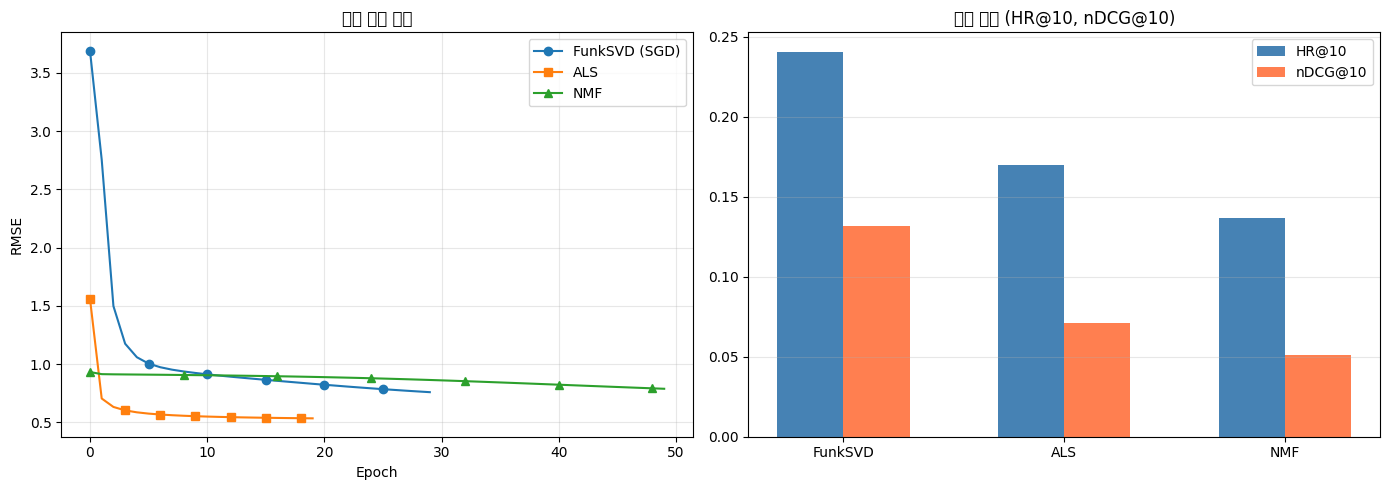

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 학습 곡선 (RMSE vs Epoch) ──
# 에포크가 진행될수록 RMSE가 낮아지는지, 어디서 수렴하는지 확인
axes[0].plot(rmse_history_svd, label='FunkSVD (SGD)', marker='o', markevery=5)
axes[0].plot(rmse_history_als, label='ALS', marker='s', markevery=3)
axes[0].plot(rmse_history_nmf, label='NMF', marker='^', markevery=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')  # 낮을수록 예측이 정확
axes[0].set_title('학습 곡선 비교')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── 모델별 HR@10, nDCG@10 비교 (막대 그래프) ──
models = ['FunkSVD', 'ALS', 'NMF']
hrs = [hr_svd, hr_als, hr_nmf]
ndcgs = [ndcg_svd, ndcg_als, ndcg_nmf]
x = np.arange(len(models))
# 두 지표를 나란히 배치 (offset -0.15, +0.15)
axes[1].bar(x - 0.15, hrs, 0.3, label='HR@10', color='steelblue')
axes[1].bar(x + 0.15, ndcgs, 0.3, label='nDCG@10', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_title('모델 비교 (HR@10, nDCG@10)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53596 (\N{HANGUL SYLLABLE TEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

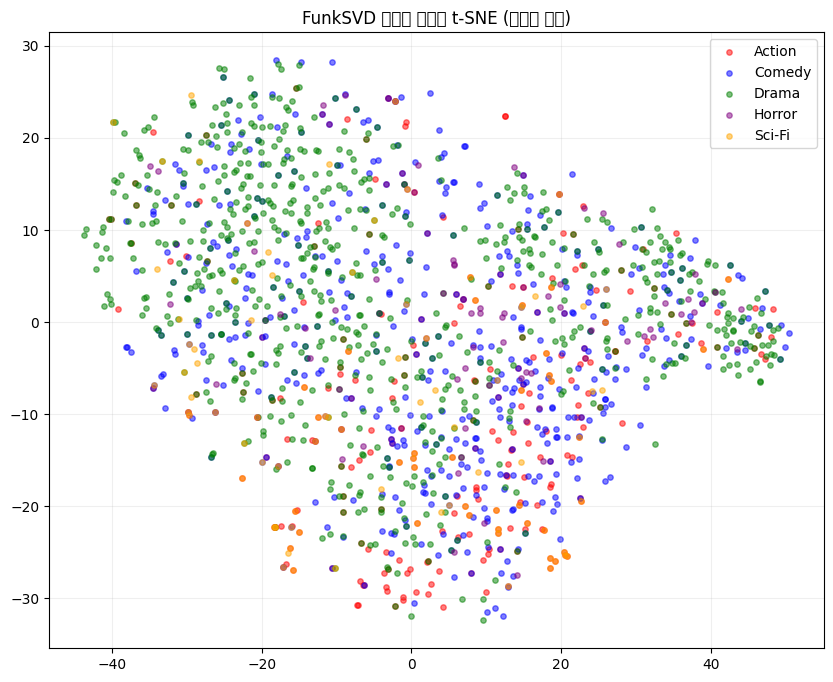

In [10]:
from sklearn.manifold import TSNE

# ── FunkSVD 아이템 임베딩을 t-SNE로 2D 투영 ──
# t-SNE: 고차원 데이터의 이웃 구조를 보존하면서 2D로 축소하는 시각화 기법
# perplexity: "각 점이 몇 개의 이웃을 고려할지" (보통 5~50 사이)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Q_2d = tsne.fit_transform(Q_svd)  # (n_items, 20) → (n_items, 2)

# ── 대표 장르 5개만 시각화 ──
top_genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi']
genre_idx = {g: genre_cols.index(g) for g in top_genres}  # 장르명 → 열 인덱스
colors = ['red', 'blue', 'green', 'purple', 'orange']

plt.figure(figsize=(10, 8))
for genre, color in zip(top_genres, colors):
    gi = genre_idx[genre]
    mask_g = item_genres[:, gi] == 1  # 해당 장르에 속하는 아이템 마스크
    # 해당 장르 아이템만 scatter로 표시
    plt.scatter(Q_2d[mask_g, 0], Q_2d[mask_g, 1], c=color, label=genre, alpha=0.5, s=15)
plt.title('FunkSVD 아이템 임베딩 t-SNE (장르별 색상)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()